<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [2]:
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette='summer')

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
!pip install datasets

In [5]:
!pip install transformers

In [6]:
import transformers
from datasets import load_dataset

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [8]:
df = pd.read_excel('/kaggle/input/datasets/djony19/data-problems-translated/data_problems_translated.xlsx')

In [9]:
df

,Unnamed: 0,problem_text,topic
0,0,To prove that the sum of the numbers of the ex...,number_theory
1,1,( b) Will the statement of the previous challe...,number_theory
2,2,The quadratic three-member graph with the coef...,polynoms
3,3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,4,"Dima, who came from Vrunlandia, said that ther...",graphs
...,...,...,...
5268,5268,Can the number n! end with the figures of 76.0...,number_theory
5269,5269,Find all natural m and n for which m! + 12 = n2.,number_theory
5270,5270,"The correct 5,000-column has a 2001 vertebrate...",dirichlet
5271,5271,Find the maximum number N for which there are ...,number_theory


In [10]:
df['topic'].value_counts()

topic
number_theory    2396
combinatorics    1020
dirichlet         441
polynoms          426
graphs            384
geometry          371
invariant         235
Name: count, dtype: int64

In [11]:
unique_labes = df['topic'].unique()
unique_labes

array(['number_theory', 'polynoms', 'combinatorics', 'graphs', 'geometry',
       'invariant', 'dirichlet'], dtype=object)

In [12]:
lab2id = {lab: id for lab, id in zip(unique_labes, list(range(len(unique_labes))))}
id2lab ={id : lab for lab, id in lab2id.items()}

In [13]:
# Ищем максимальную длину строки
text_max_len = int(df['problem_text'].str.len().max())
text_max_len

2506

In [14]:
# Сделаем max_length 512 для начала
max_length = 512

In [15]:
class TextDataset(Dataset):
  def __init__(self, df, tokenizer, max_length=64):
    self.texts = df['problem_text'].tolist()
    self.labels = df['topic'].tolist()
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
     text = str(self.texts[idx])
     label = lab2id.get(self.labels[idx])

     encoding = self.tokenizer(
         text,
         truncation=True,
         padding='max_length',
         max_length=self.max_length,
         return_tensors='pt'
     )

     return {
         'input_ids' : encoding['input_ids'].flatten(),
         'attention_mask' : encoding['attention_mask'].flatten(),
         'label' : torch.tensor(label, dtype=torch.float)
     }

In [16]:
model_name = 'tbs17/MathBert'

In [17]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [18]:
ds = TextDataset(df, tokenizer, max_length=max_length)

In [19]:
ds[12]

{'input_ids': tensor([  101,  1996,  3595,  2326,  2038,  1050,  6074,  1516, 25604,  1010,
          4002,  2475,  1010,  1012,  1012,  1012,  1010,  4002,  2581,  1010,
          1012,  1012,  1012,  1050,  1012,  1996,  2034,  4005,  2003,  2559,
          2044,  1996,  2117,  1010,  1996,  2117,  2028,  2003,  2559,  2044,
          1996,  2353,  1010,  4385,  1012,  1010,  1050,  1011,  1045,  2003,
          2559,  2044,  1996,  2034,  2028,  1012,  6011,  2008,  1050,  2003,
          2019,  5976,  2193,  1012,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [20]:
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['topic'],
)

In [21]:
df_train['topic'].value_counts()

topic
number_theory    1916
combinatorics     816
dirichlet         353
polynoms          341
graphs            307
geometry          297
invariant         188
Name: count, dtype: int64

In [22]:
df_val['topic'].value_counts()

topic
number_theory    480
combinatorics    204
dirichlet         88
polynoms          85
graphs            77
geometry          74
invariant         47
Name: count, dtype: int64

In [23]:
train_dataset = TextDataset(
    df_train,
    tokenizer,
    max_length=max_length
)

val_dataset = TextDataset(
    df_val,
    tokenizer,
    max_length=max_length
)

In [24]:
train_dataset[200]

{'input_ids': tensor([ 101, 2169, 2266, 2038, 2028, 2767, 1998, 2028, 4099, 2000, 6011, 2008,
         1006, 1037, 1007, 1996, 2193, 1997, 2372, 2003, 2130, 1012, 1006, 1038,
         1007, 1996, 4418, 2064, 2022, 4055, 2046, 2048, 8699, 7925, 1012,  102,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0, 

In [25]:
BATCH_SIZE = 32

In [26]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [27]:
batch = next(iter(train_loader))
batch

{'input_ids': tensor([[ 101, 1006, 1038,  ...,    0,    0,    0],
         [ 101, 2424, 2035,  ...,    0,    0,    0],
         [ 101, 2000, 6011,  ...,    0,    0,    0],
         ...,
         [ 101, 3998, 4879,  ...,    0,    0,    0],
         [ 101, 1999, 1996,  ...,    0,    0,    0],
         [ 101, 2045, 2024,  ...,    0,    0,    0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'label': tensor([3., 0., 0., 0., 5., 0., 0., 2., 1., 6., 1., 0., 6., 4., 0., 0., 3., 0.,
         0., 0., 1., 0., 5., 0., 6., 0., 2., 6., 0., 2., 0., 5.])}

In [28]:
batch['input_ids'].shape

torch.Size([32, 512])

In [29]:
model = transformers.AutoModel.from_pretrained(model_name)

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [31]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

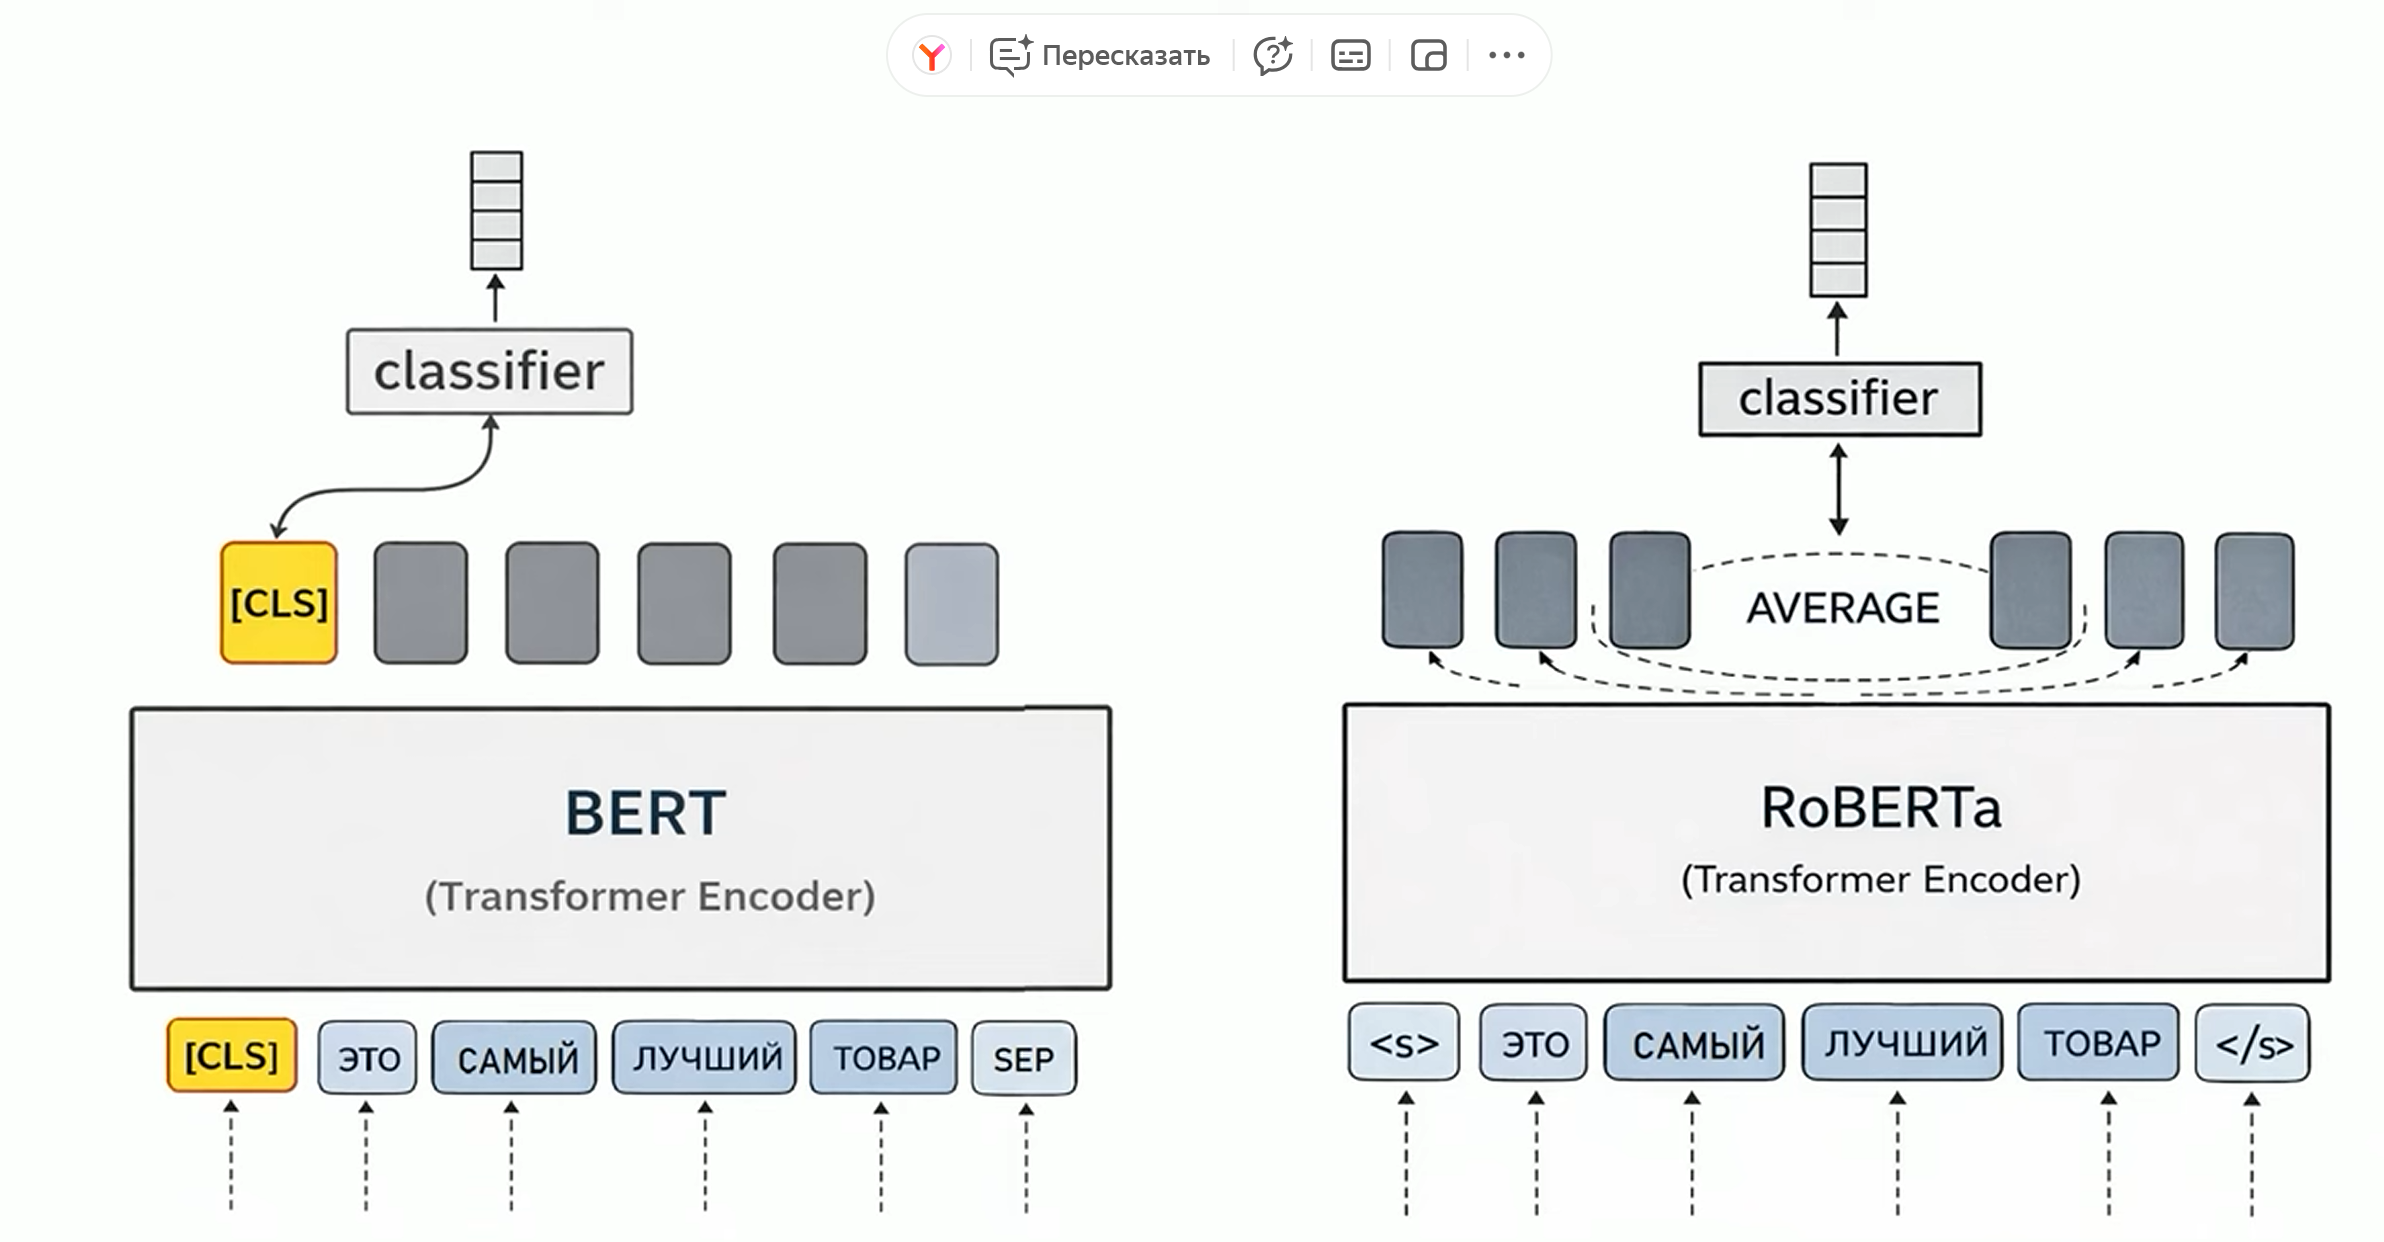

In [32]:
### This is just an interface example. You may change it if you want.
from typing import Union

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int):
        super().__init__()
        if isinstance(base_transformer_model, str):
            self.backbone = transformers.AutoModel.from_pretrained(base_transformer_model)
        else:
            self.backbone = base_transformer_model
        self.hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Linear(self.hidden_size, num_classes)
        self.dropout = nn.Dropout(p=0.3)
        # YOUR CODE: create additional layers for classfication

    def forward(self, input_ids, attention_mask):
        # YOUR CODE: propagate inputs through the model. Return dict with logits
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :] # для BERT подобных моделей берем первый эмбеддинг CLS - который включает всю информацию

        logits = self.classifier(self.dropout(cls_embedding))
        # outputs = {<YOUR CODE>}
        return {"logits": logits} # YOUR CODE

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [33]:
class_model = TransformerClassificationModel(base_transformer_model=model_name, num_classes=len(unique_labes))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
      param.requires_grad = False

    total = sum(1 for _ in model.backbone.parameters())
    frozen = sum(1 for p in model.backbone.parameters() if not p.requires_grad)
    print(f"Backbone: {frozen}/{total} параметров заморожено")

In [35]:
freeze_backbone_function(class_model)

Backbone: 199/199 параметров заморожено


### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [36]:
import copy

def train_transformer(transformer_model, freeze_backbone=True):
    model = copy.deepcopy(transformer_model)
    ### YOUR CODE IS HERE
    num_epochs = 5

    if freeze_backbone:
      freeze_backbone_function(model)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

    model.train()
    for epoch in tqdm(range(num_epochs)):
      train_losses = []
      for batch in tqdm(train_loader, desc=f'Training epoch {epoch}:'):

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device).long()

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        logits = outputs['logits']

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

      avg_train_loss = sum(train_losses) / len(train_losses)


      model.eval()
      val_losses = []
      correct = 0
      total = 0

      with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Validaion epoch {epoch}:'):

          input_ids = batch['input_ids'].to(device)
          attention_mask = batch['attention_mask'].to(device)
          labels = batch['label'].to(device).long()

          outputs = model(input_ids, attention_mask)
          logits = outputs['logits']
          loss = criterion(logits, labels)
          val_losses.append(loss.item())

          preds = logits.argmax(dim=1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      avg_val_loss = sum(val_losses) / len(val_losses)
      val_acc = correct / total if total > 0 else 0.0

      print(f"\nEpoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
      model.train()

    return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [83]:
rubert_tiny_transformer_model = TransformerClassificationModel('cointegrated/rubert-tiny2', len(unique_labes))
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, freeze_backbone=True)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Backbone: 55/55 параметров заморожено


  0%|          | 0/5 [00:00<?, ?it/s]

Training epoch 0::   0%|          | 0/132 [00:00<?, ?it/s]

...

Validaion epoch 3::   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 3 | Train Loss: 1.7214 | Val Loss: 1.6536 | Val Acc: 0.4370


Training epoch 4::   0%|          | 0/132 [00:00<?, ?it/s]

Validaion epoch 4::   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 4 | Train Loss: 1.6610 | Val Loss: 1.6164 | Val Acc: 0.4512


In [81]:
rubert_tiny_transformer_model = TransformerClassificationModel('cointegrated/rubert-tiny2', len(unique_labes))
rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/5 [00:00<?, ?it/s]

Training epoch 0::   0%|          | 0/66 [00:00<?, ?it/s]

Validaion epoch 0::   0%|          | 0/17 [00:00<?, ?it/s]

...

Validaion epoch 3::   0%|          | 0/17 [00:00<?, ?it/s]


Epoch 3 | Train Loss: 1.2624 | Val Loss: 1.1354 | Val Acc: 0.5706


Training epoch 4::   0%|          | 0/66 [00:00<?, ?it/s]

Validaion epoch 4::   0%|          | 0/17 [00:00<?, ?it/s]


Epoch 4 | Train Loss: 1.1794 | Val Loss: 1.0921 | Val Acc: 0.5773


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [101]:
def cleanup_gpu():
    import torch, gc
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

In [102]:
cleanup_gpu()

In [2]:
!nvidia-smi

Wed Apr 22 16:18:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [87]:
math_bert_transformer_model = TransformerClassificationModel('tbs17/MathBert', len(unique_labes))
math_bert_finetuned_with_freezed_backbone = train_transformer(math_bert_transformer_model, freeze_backbone=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Backbone: 199/199 параметров заморожено


  0%|          | 0/5 [00:00<?, ?it/s]

Training epoch 0::   0%|          | 0/132 [00:00<?, ?it/s]

...

Validaion epoch 3::   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 3 | Train Loss: 1.6171 | Val Loss: 1.5640 | Val Acc: 0.4417


Training epoch 4::   0%|          | 0/132 [00:00<?, ?it/s]

Validaion epoch 4::   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 4 | Train Loss: 1.5920 | Val Loss: 1.5395 | Val Acc: 0.4445


In [39]:
math_bert_transformer_model = TransformerClassificationModel('tbs17/MathBert', len(unique_labes))
math_bert_full_finetuned = train_transformer(math_bert_transformer_model, freeze_backbone=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/5 [00:00<?, ?it/s]

Training epoch 0::   0%|          | 0/132 [00:00<?, ?it/s]

Validaion epoch 0::   0%|          | 0/33 [00:00<?, ?it/s]

...

Validaion epoch 3::   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 3 | Train Loss: 0.6338 | Val Loss: 1.1796 | Val Acc: 0.5422


Training epoch 4::   0%|          | 0/132 [00:00<?, ?it/s]

Validaion epoch 4::   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 4 | Train Loss: 0.5430 | Val Loss: 1.3155 | Val Acc: 0.5498


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

Если при вызове модели передать output_attentions=True, в outputs появится поле attentions.
Это кортеж из num_layers тензоров формы [batch, num_heads, seq_len, seq_len].

In [76]:
from typing import List

def draw_first_layer_attention_maps(attention_head_ids: List, 
                                    text: str, 
                                    model: TransformerClassificationModel,
                                    tokenizer):
    encoding = tokenizer(
         text,
         padding=True,
         return_tensors='pt'
     )

    device = next(model.backbone.parameters()).device
    encoding = {k: v.to(device) for k, v in encoding.items()}

    model.backbone.config._attn_implementation = "eager"
    if hasattr(model.backbone, '_attn_implementation'):
        model.backbone._attn_implementation = "eager"

    outputs = model.backbone(**encoding, output_attentions=True)
        
    layer_1_attn = outputs.attentions[0]
    attn_map = layer_1_attn[:, attention_head_ids, :, :].mean(dim=1).squeeze(0)
    attn_map_np = attn_map.cpu().detach().numpy()

    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'].squeeze(0))

    fig, ax = plt.subplots(figsize=(10, 10))
    # ax.set_xticks(list(range(len(tokens))), tokens)
    # ax.set_yticks(list(range(len(tokens))), tokens)
    # sns.heatmap(attn_map_np)
    # plt.show()

    sns.heatmap(attn_map_np, 
                xticklabels=tokens, 
                yticklabels=tokens, 
                vmin=0, vmax=1,  
                ax=ax)
                
    ax.set_title(f'Карта внимания (Голова: {attention_head_ids})', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

Здесь обьратился за помощью к ИИ - достать слои внимания оказалось не тривиальной задачей

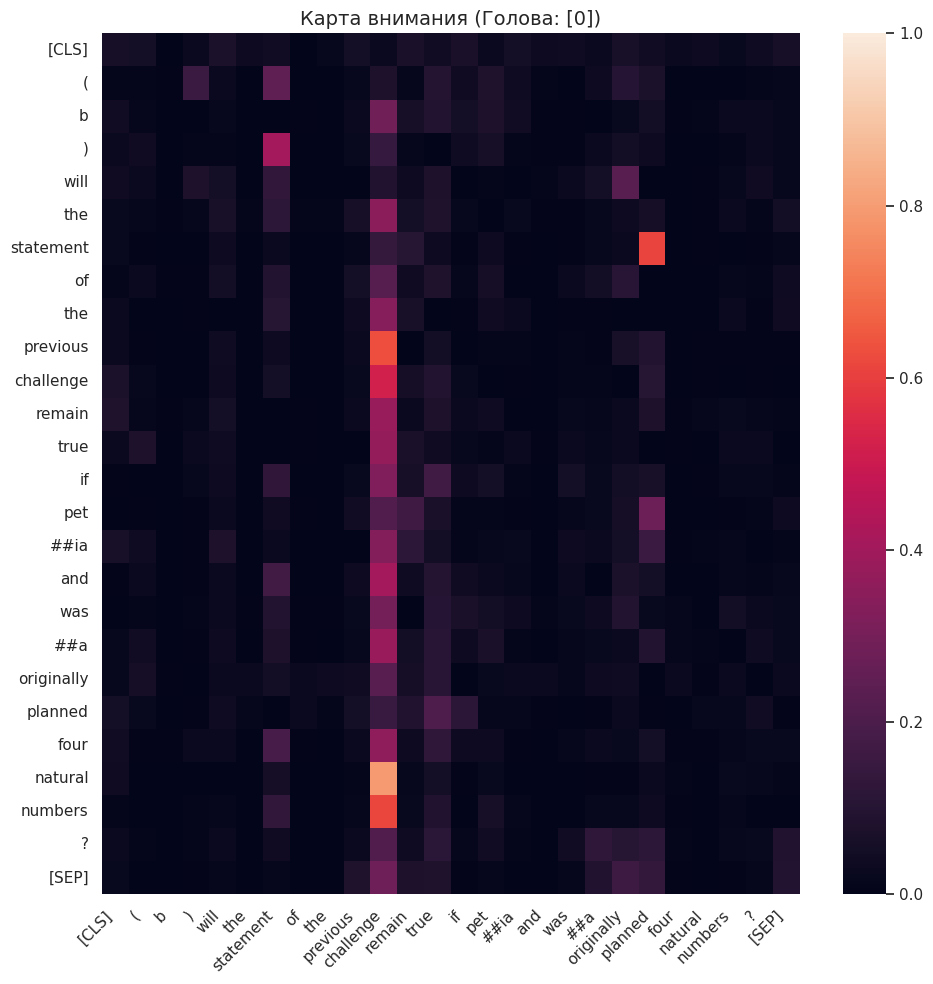

In [77]:
draw_first_layer_attention_maps([0,], df['problem_text'][1], math_bert_full_finetuned, tokenizer)

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [84]:
math_bert_model = TransformerClassificationModel('tbs17/MathBert', len(unique_labes))
math_bert_tokenizer = transformers.AutoTokenizer.from_pretrained('tbs17/MathBert')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


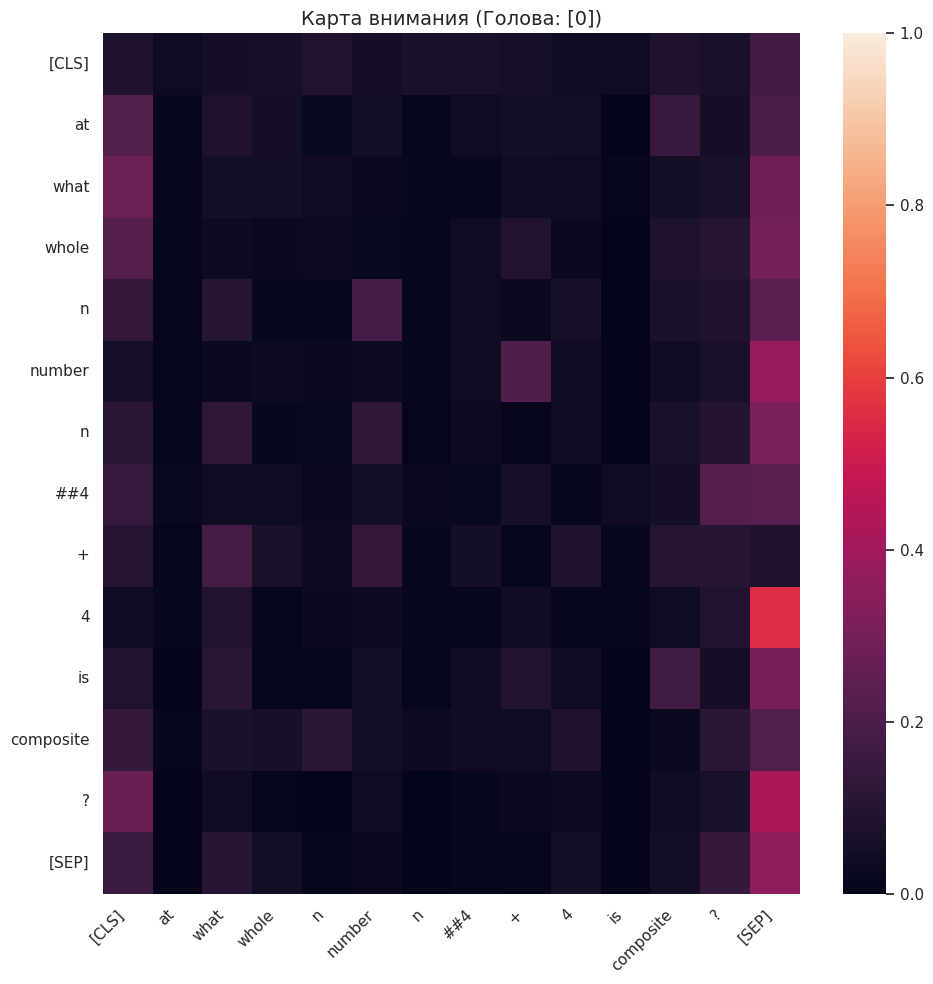

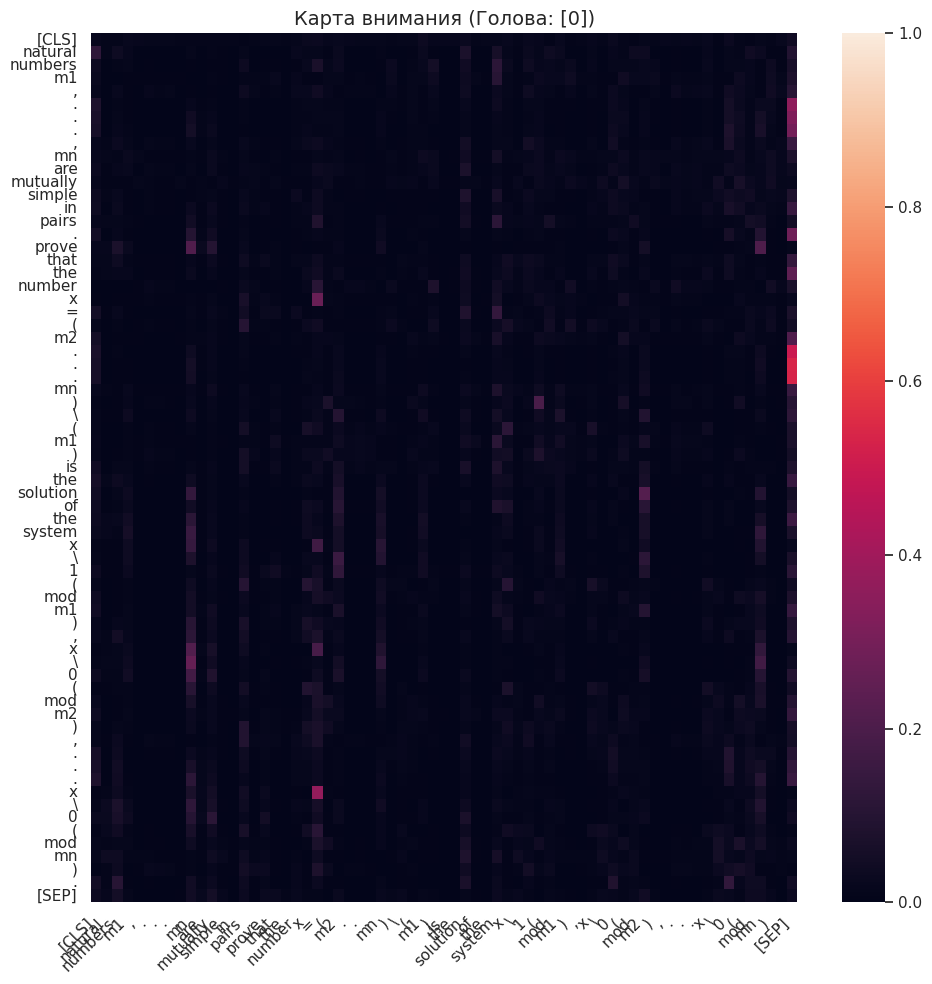

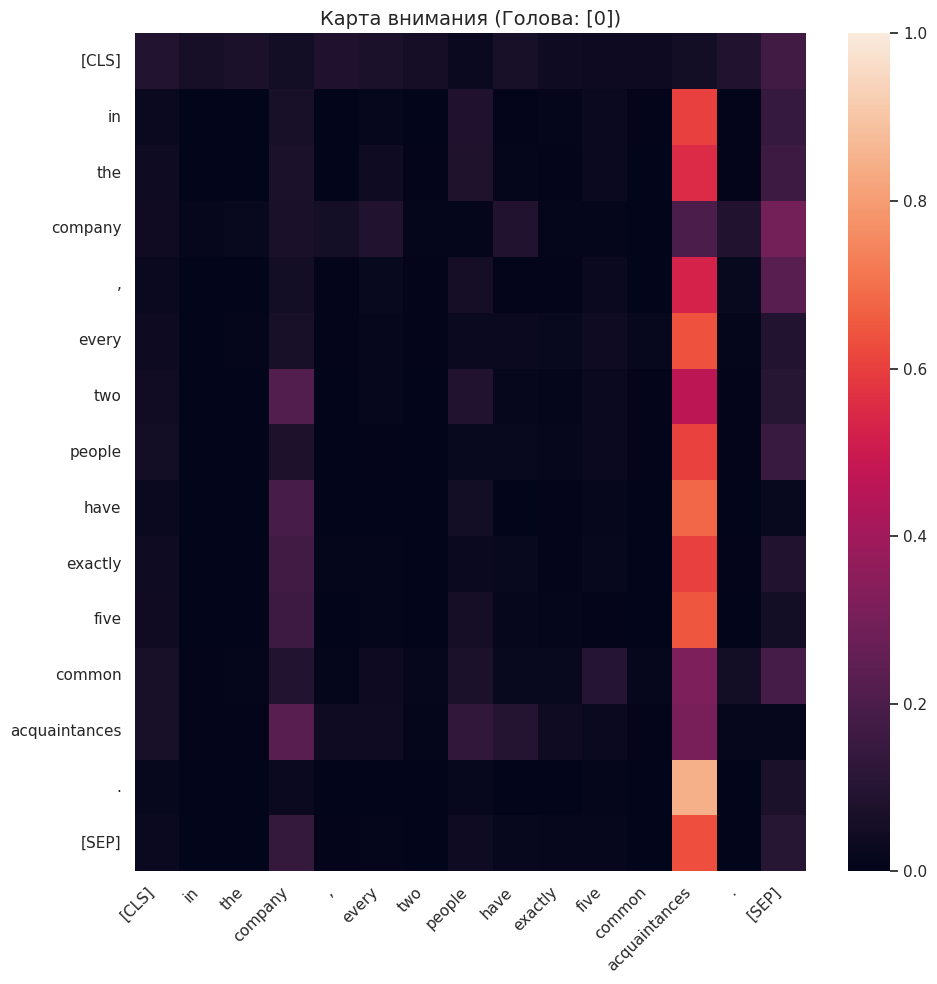

In [85]:
text_ids = [32, 54, 111]
for ids in text_ids:
    draw_first_layer_attention_maps([0,], df['problem_text'][ids], math_bert_model, math_bert_tokenizer)

In [81]:
rubert_tiny_model = TransformerClassificationModel('cointegrated/rubert-tiny2', len(unique_labes))
rubert_tiny_tokenizer = transformers.AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

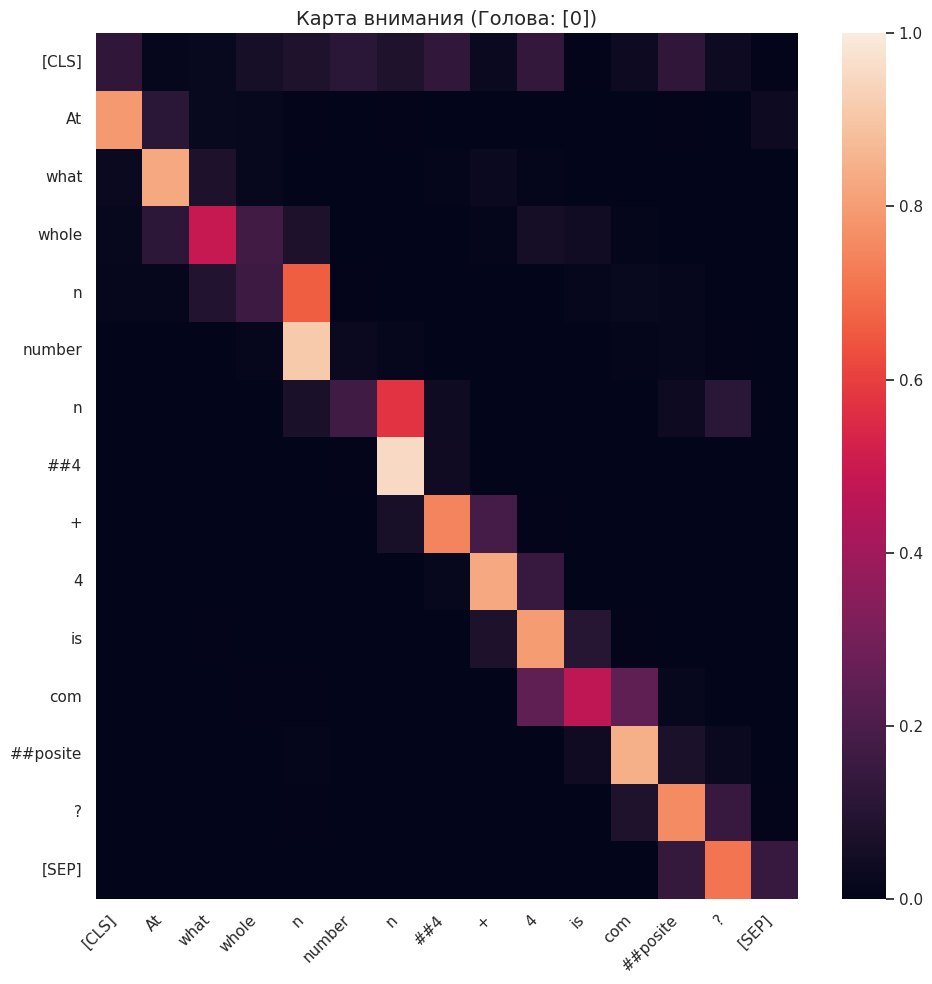

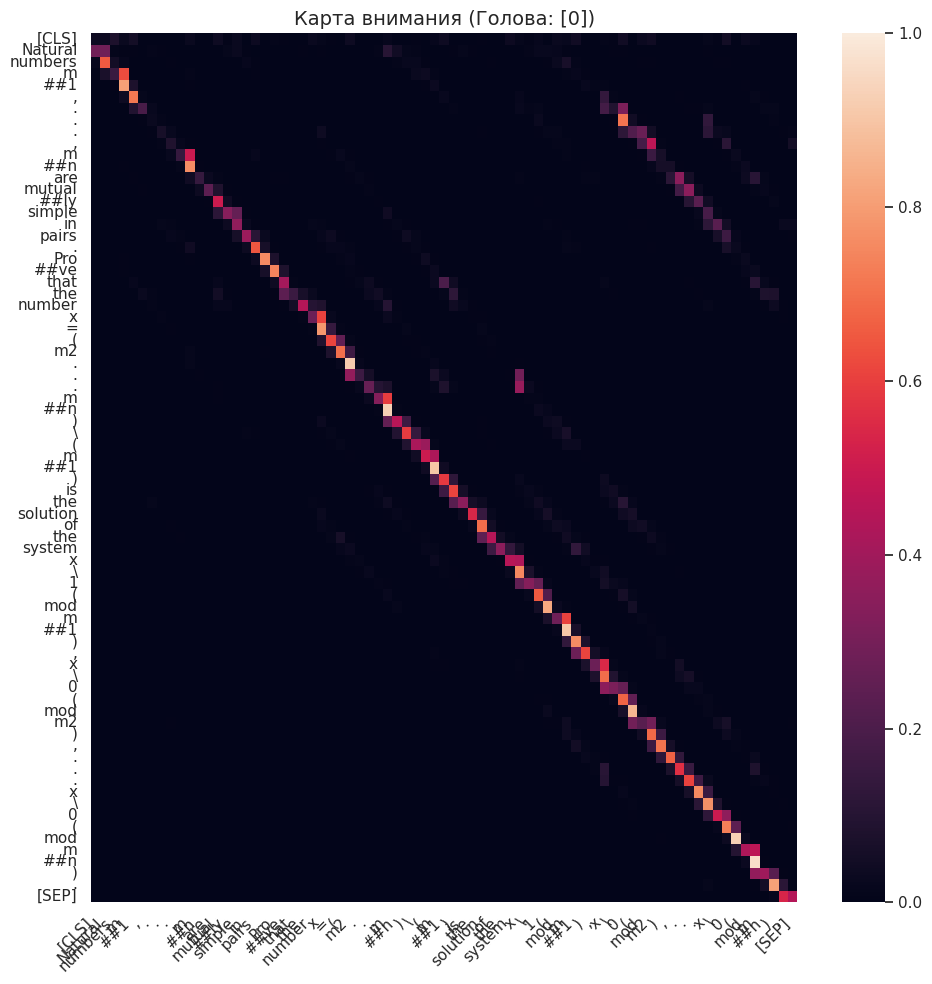

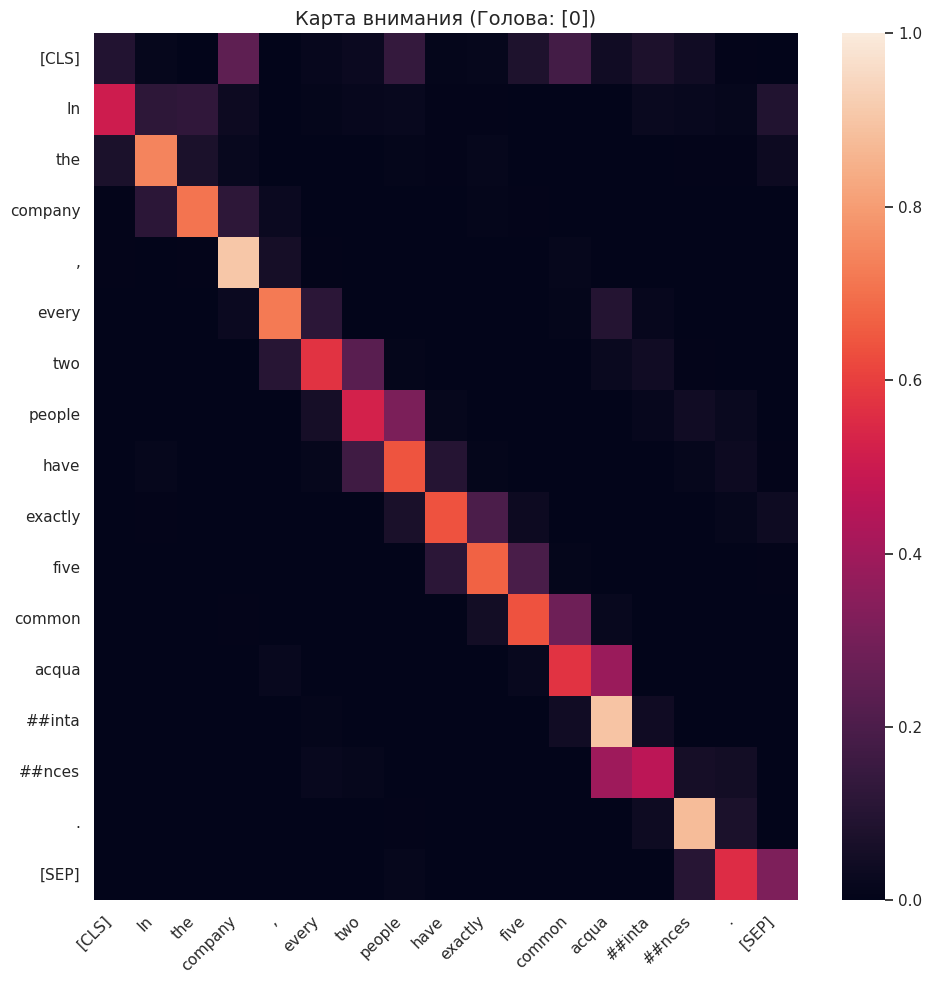

In [82]:
text_ids = [32, 54, 111]
for ids in text_ids:
    draw_first_layer_attention_maps([0,], df['problem_text'][ids], rubert_tiny_model, rubert_tiny_tokenizer)

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

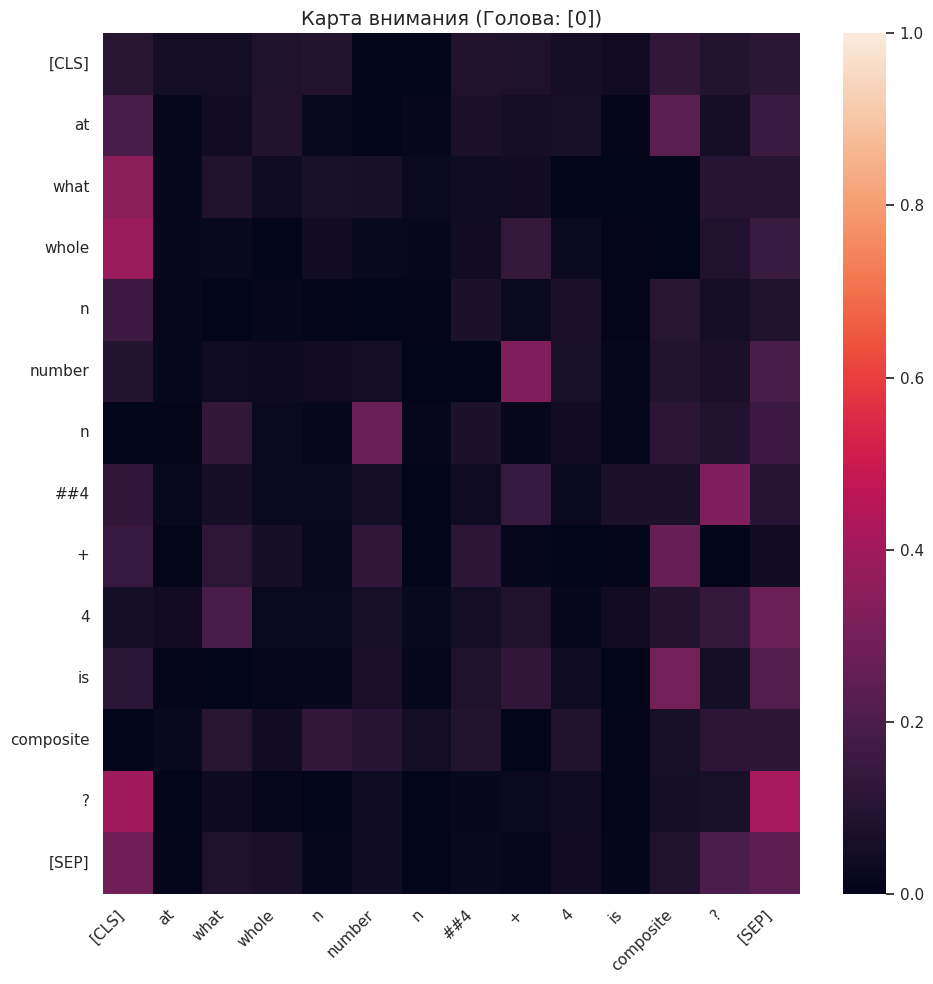

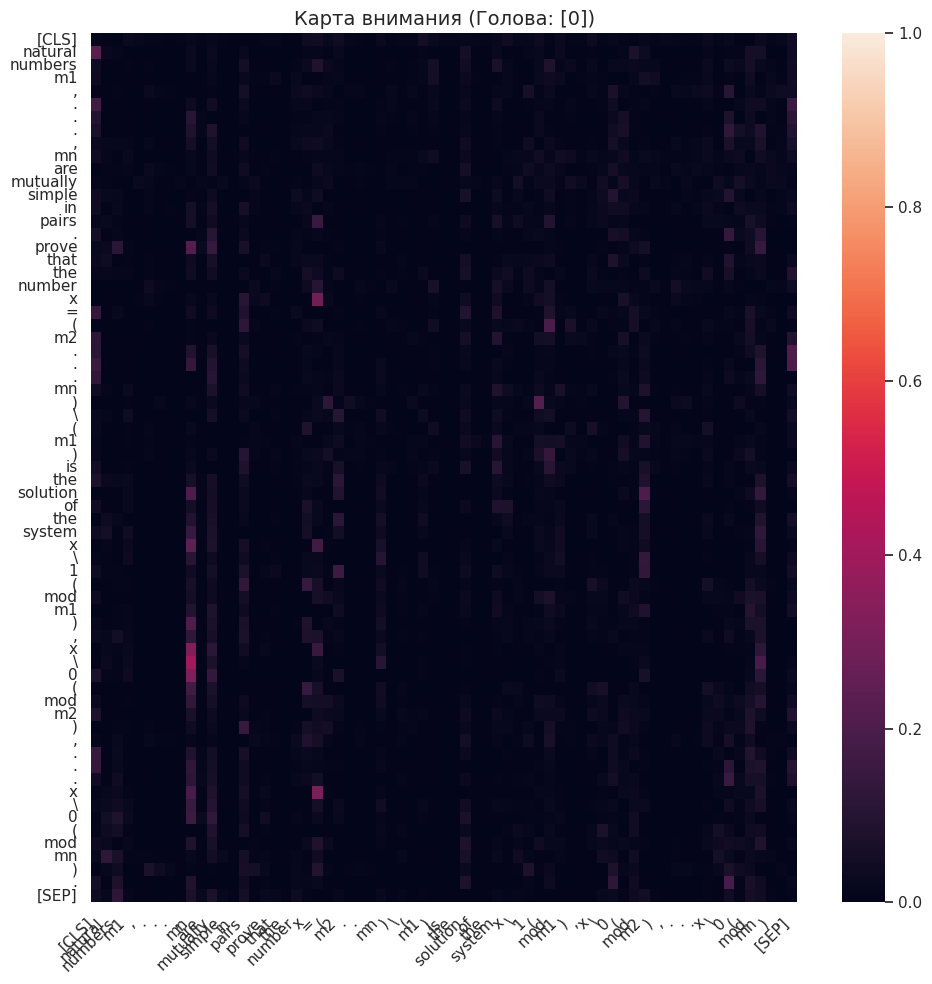

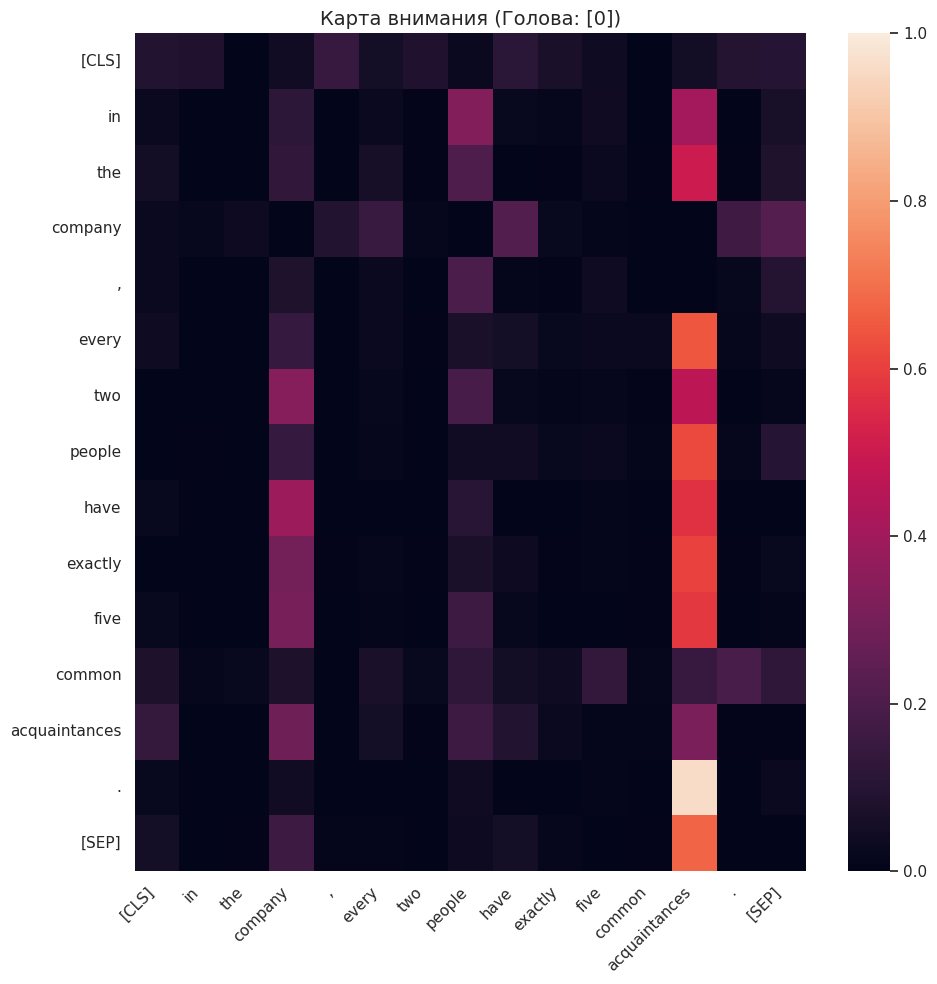

In [86]:

text_ids = [32, 54, 111]
for ids in text_ids:
    draw_first_layer_attention_maps([0,], df['problem_text'][ids], math_bert_full_finetuned, math_bert_tokenizer)

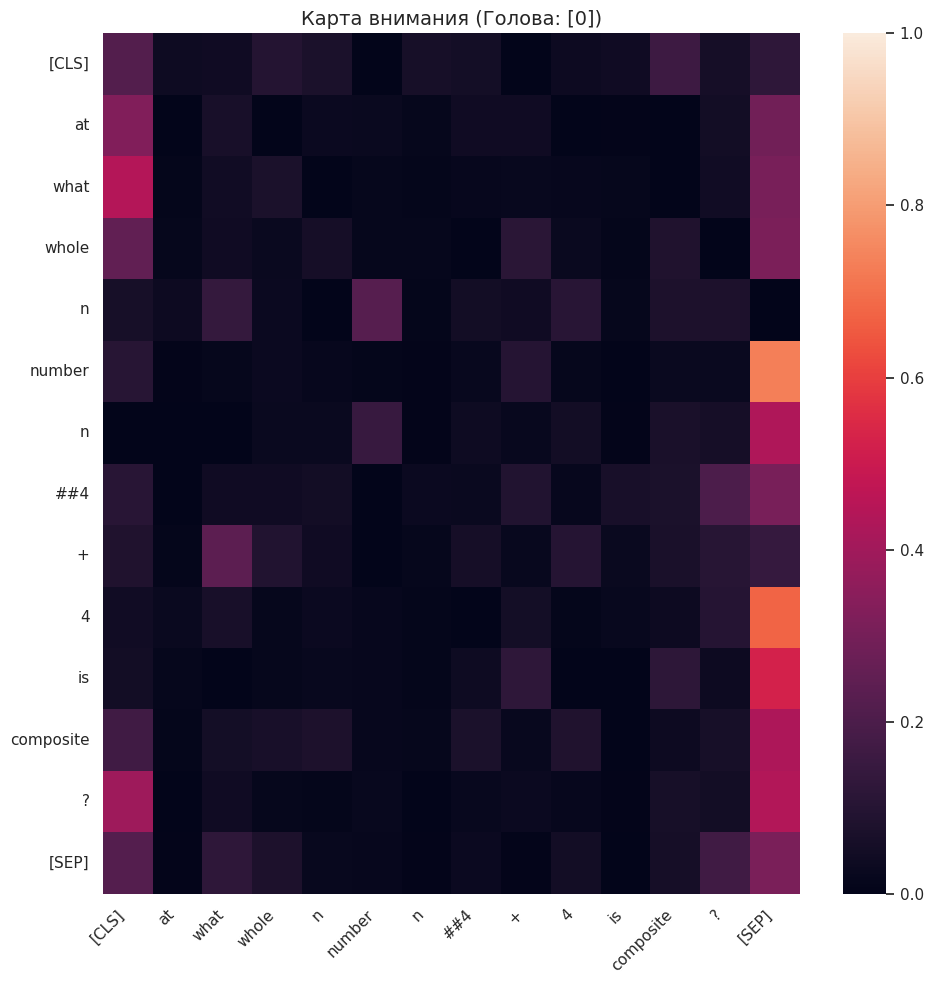

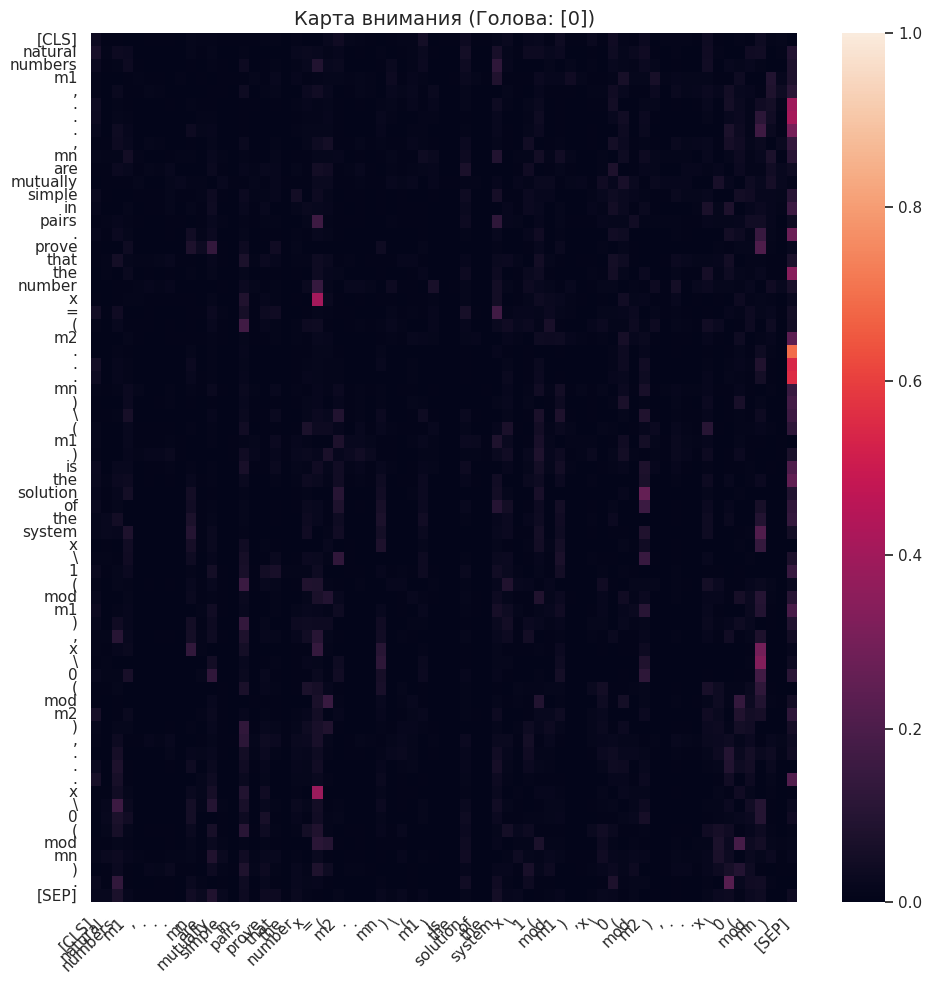

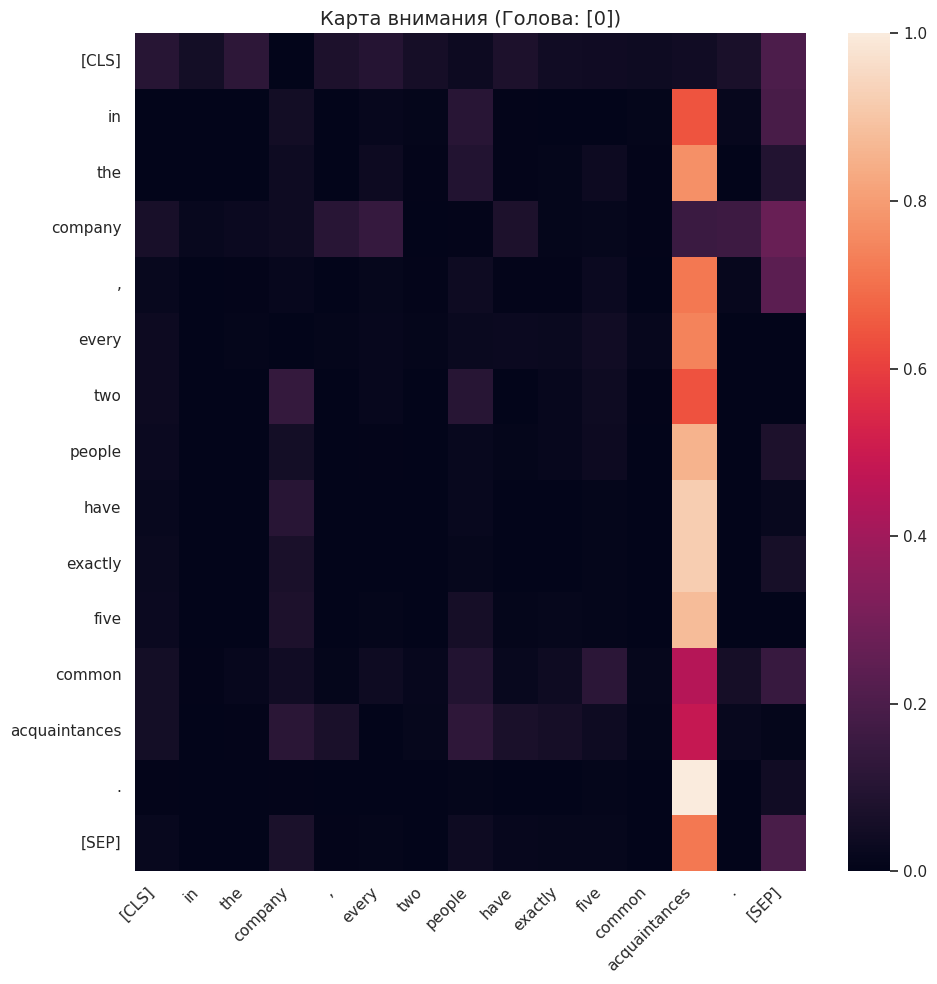

In [88]:
text_ids = [32, 54, 111]
for ids in text_ids:
    draw_first_layer_attention_maps([0,], df['problem_text'][ids], math_bert_finetuned_with_freezed_backbone, math_bert_tokenizer)

Для моделей с замороженными весами карты внимания не изменились - мы обучаем только голову, принимающее решение при классификации. С размороженными немного изменились - фокус сместился в область мат задач, но на таком объеме данным и малом количестве эпох это не сильно бросается в глаза. 